# Experiment 7 — Sentiment Analysis using LSTM and Simple RNN

**Aim:** Build a sentiment analysis model using an Embedding layer and LSTM on the IMDB movie reviews dataset, evaluate its performance, and compare it with a Simple RNN.

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, SimpleRNN, Dense


In [2]:
# Load IMDB dataset
vocab_size = 10000
max_len = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

print('Training samples:', len(x_train))
print('Testing samples:', len(x_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training samples: 25000
Testing samples: 25000


In [3]:
# LSTM model
lstm_model = Sequential([Embedding(vocab_size, 64, input_length=max_len), LSTM(64), Dense(1, activation='sigmoid')])
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.2)
lstm_loss, lstm_acc = lstm_model.evaluate(x_test, y_test, verbose=0)
print('LSTM Test Accuracy:', round(lstm_acc, 4))

C:\Users\himan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 59ms/step - accuracy: 0.7838 - loss: 0.4423 - val_accuracy: 0.8688 - val_loss: 0.3222
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 79ms/step - accuracy: 0.9034 - loss: 0.2466 - val_accuracy: 0.8300 - val_loss: 0.4378
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 93ms/step - accuracy: 0.9314 - loss: 0.1791 - val_accuracy: 0.8578 - val_loss: 0.3967
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.9455 - loss: 0.1484 - val_accuracy: 0.8598 - val_loss: 0.3558
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.9621 - loss: 0.1081 - val_accuracy: 0.8390 - val_loss: 0.3732
LSTM Test Accuracy: 0.8456


In [4]:
# Simple RNN model
rnn_model = Sequential([Embedding(vocab_size, 64, input_length=max_len), SimpleRNN(64), Dense(1, activation='sigmoid')])
rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
rnn_model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.2)
rnn_loss, rnn_acc = rnn_model.evaluate(x_test, y_test, verbose=0)
print('Simple RNN Test Accuracy:', round(rnn_acc, 4))

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.6234 - loss: 0.6308 - val_accuracy: 0.7756 - val_loss: 0.4858
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.7352 - loss: 0.5497 - val_accuracy: 0.5582 - val_loss: 0.9738
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.7679 - loss: 0.4887 - val_accuracy: 0.7692 - val_loss: 0.4994
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8792 - loss: 0.2935 - val_accuracy: 0.8312 - val_loss: 0.4436
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.9219 - loss: 0.2071 - val_accuracy: 0.8256 - val_loss: 0.4535
Simple RNN Test Accuracy: 0.8181


In [5]:
print('\n=== Accuracy Comparison ===')
print('LSTM       :', round(lstm_acc, 4))
print('Simple RNN :', round(rnn_acc, 4))
print('Better Model:', 'LSTM' if lstm_acc > rnn_acc else 'Simple RNN')


=== Accuracy Comparison ===
LSTM       : 0.8456
Simple RNN : 0.8181
Better Model: LSTM


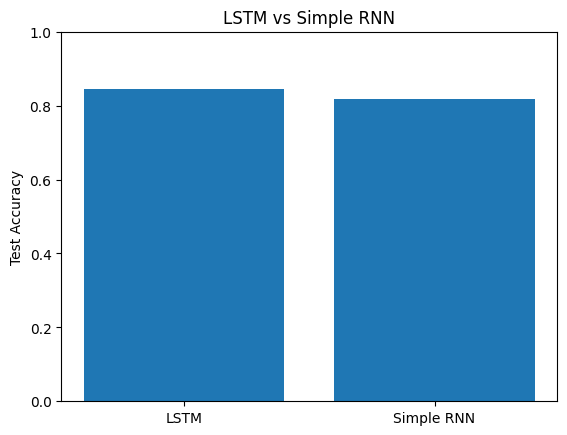

In [6]:
import matplotlib.pyplot as plt
plt.bar(['LSTM', 'Simple RNN'], [lstm_acc, rnn_acc])
plt.ylabel('Test Accuracy')
plt.title('LSTM vs Simple RNN')
plt.ylim(0, 1)
plt.show()

### Result
The test accuracies of LSTM and Simple RNN are compared. The model with higher test accuracy performs better on IMDB sentiment classification.